In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, normaltest, probplot, skew

In [2]:
current_dir = Path.cwd()
division_data_dir = current_dir.parent.parent / "data" / "division"
targets_file = division_data_dir / "targets.csv"

# Loading the targets

In [3]:
targets_df = pd.read_csv(targets_file)
print(f"Targets instances: {targets_df.shape[0]}")
targets_df.head()

Targets instances: 17329


,window_id,has_start,start_idx,start_norm,has_end,end_idx,end_norm
0,0,1,64,0.288288,0,-1,-1.0
1,1,1,44,0.198198,0,-1,-1.0
2,2,1,24,0.108108,0,-1,-1.0
3,3,1,4,0.018018,0,-1,-1.0
4,4,0,-1,-1.000000,0,-1,-1.0


We can see that we need to solve complex problem with 2 classification models (has_start and has_end) and 2 regression models (start_norm and end_norm).

# Checking if there are no missing values

In [4]:
targets_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17329 entries, 0 to 17328
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   window_id   17329 non-null  int64  
 1   has_start   17329 non-null  int64  
 2   start_idx   17329 non-null  int64  
 3   start_norm  17329 non-null  float64
 4   has_end     17329 non-null  int64  
 5   end_idx     17329 non-null  int64  
 6   end_norm    17329 non-null  float64
dtypes: float64(2), int64(5)
memory usage: 947.8 KB


All values are in place, so we can move on.

# Checking if there is any class disbalance in classification part (has_start and has_end)

has_start:
  Class 0: 2696 (15.56%)
  Class 1: 14633 (84.44%)
  Imbalance ratio (1 / 0): 5.43

has_end:
  Class 0: 3401 (19.63%)
  Class 1: 13928 (80.37%)
  Imbalance ratio (1 / 0): 4.10



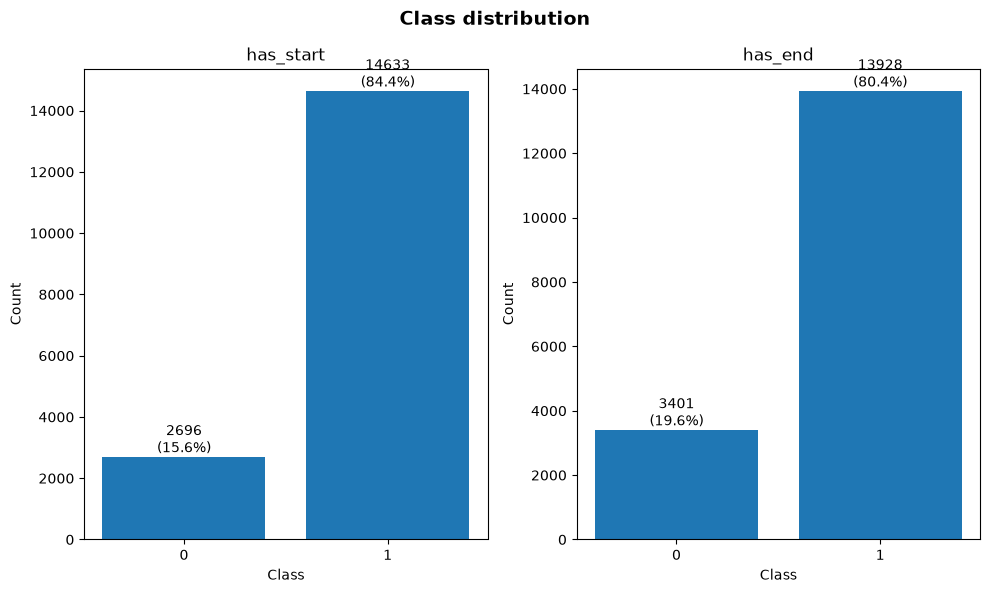

In [5]:
targets = ["has_start", "has_end"]

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
fig.suptitle("Class distribution", fontsize=14, fontweight="bold")


for ax, target in zip(axes, targets):
    counts = Counter(targets_df[target].values)

    n_0 = counts.get(0, 0)
    n_1 = counts.get(1, 0)
    total = n_0 + n_1

    p_0 = n_0 / total * 100
    p_1 = n_1 / total * 100

    ratio = n_1 / n_0 if n_0 > 0 else np.inf

    # Statistics
    print(f"{target}:")
    print(f"  Class 0: {n_0} ({p_0:.2f}%)")
    print(f"  Class 1: {n_1} ({p_1:.2f}%)")
    print(f"  Imbalance ratio (1 / 0): {ratio:.2f}\n")

    # Sanity check
    if n_0 == 0 or n_1 == 0:
        print("  WARNING: only one class is present!")

    # Plot
    classes = [0, 1]
    values = [n_0, n_1]

    bars = ax.bar(classes, values)

    ax.set_title(target)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticks(classes)

    for bar, percentage in zip(bars, [p_0, p_1]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height())}\n({percentage:.1f}%)",
            ha="center",
            va="bottom"
        )


plt.tight_layout()
plt.show()

Both target variables are moderately imbalanced. The positive class represents 84.4% of samples for has_start and 80.4% for has_end. Therefore, class imbalance should be taken into account during model training, and accuracy should not be used as the only evaluation metric.

# Analyzing the distribution of regression targets (start_norm and end_norm)

start_norm
N:                14633
Mean:             0.450983
Median:           0.427928
Std:              0.285645
Min:              0.000000
Q1 (25%):         0.198198
Q3 (75%):         0.693694
Max:              1.000000
IQR:              0.495495
Skewness:         0.179010
Kurtosis:         -1.169716
CV:               0.633383

Outlier bounds:   [-0.545045, 1.436937]
Outliers:         0
Outlier ratio:    0.00%

Normality p-value: 0
Normality test:   significant deviation from normality
end_norm
N:                13928
Mean:             0.503027
Median:           0.504505
Std:              0.289765
Min:              0.000000
Q1 (25%):         0.252252
Q3 (75%):         0.752252
Max:              1.000000
IQR:              0.500000
Skewness:         -0.005692
Kurtosis:         -1.199065
CV:               0.576044

Outlier bounds:   [-0.497748, 1.502252]
Outliers:         0
Outlier ratio:    0.00%

Normality p-value: 0
Normality test:   significant deviation from normality

Summary:


,Variable,N,Mean,Median,Std,Min,Q1,Q3,Max,IQR,Skewness,Kurtosis,Outliers,Outlier %
0,start_norm,14633,0.451,0.4279,0.2856,0.0,0.1982,0.6937,1.0,0.4955,0.1790,-1.1697,0,0.0
1,end_norm,13928,0.503,0.5045,0.2898,0.0,0.2523,0.7523,1.0,0.5000,-0.0057,-1.1991,0,0.0


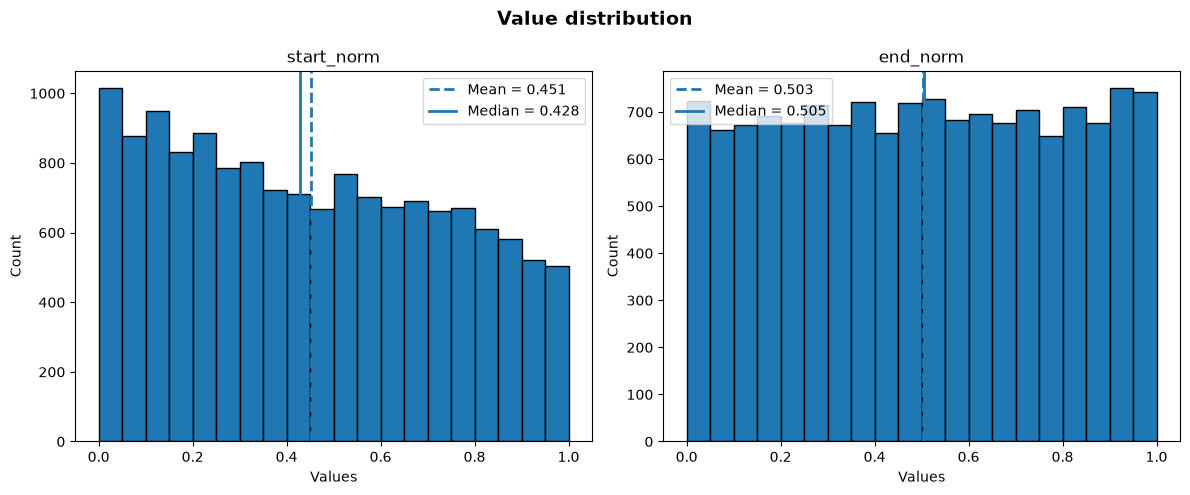

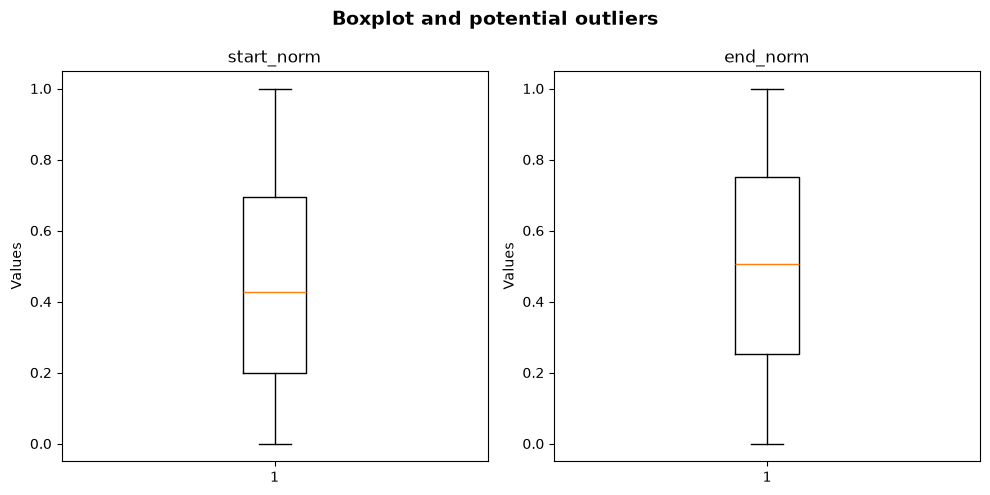

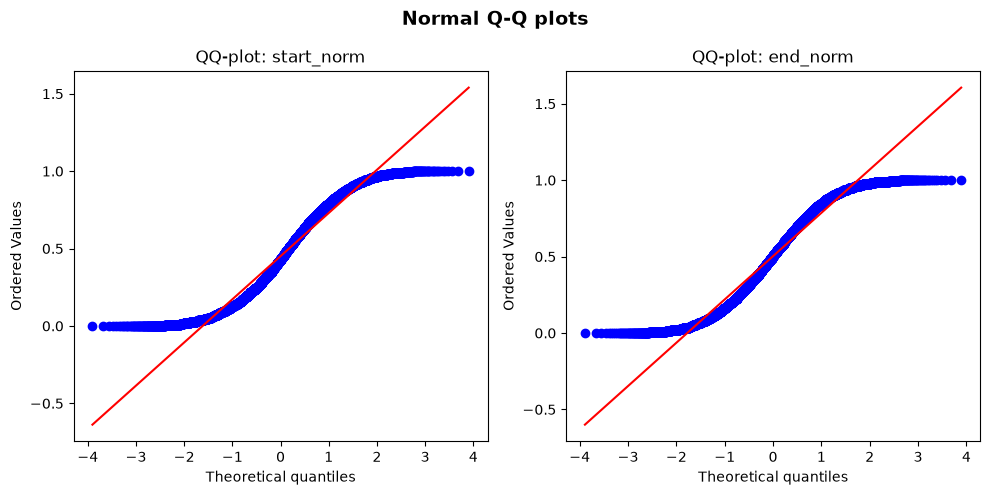

In [6]:
start_norm = targets_df.loc[targets_df["has_start"] == 1, "start_norm"].values
end_norm = targets_df.loc[targets_df["has_end"] == 1, "end_norm"].values


def analyze_distribution(data, name):
    mean = np.mean(data)
    median = np.median(data)
    std = np.std(data, ddof=1)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    skewness = skew(data)
    kurt = kurtosis(data)  # Fisher=True by default, normal = 0

    cv = std / abs(mean) if mean != 0 else np.nan

    # D'Agostino's K² normality test
    if len(data) >= 8:
        _, p_value = normaltest(data)
    else:
        _, p_value = np.nan, np.nan

    print("=" * 60)
    print(f"{name}")
    print("=" * 60)

    print(f"N:                {len(data)}")
    print(f"Mean:             {mean:.6f}")
    print(f"Median:           {median:.6f}")
    print(f"Std:              {std:.6f}")
    print(f"Min:              {np.min(data):.6f}")
    print(f"Q1 (25%):         {q1:.6f}")
    print(f"Q3 (75%):         {q3:.6f}")
    print(f"Max:              {np.max(data):.6f}")
    print(f"IQR:              {iqr:.6f}")
    print(f"Skewness:         {skewness:.6f}")
    print(f"Kurtosis:         {kurt:.6f}")
    print(f"CV:               {cv:.6f}")

    print()
    print(f"Outlier bounds:   [{lower_bound:.6f}, {upper_bound:.6f}]")
    print(f"Outliers:         {len(outliers)}")
    print(f"Outlier ratio:    {len(outliers) / len(data) * 100:.2f}%")

    print()
    print(f"Normality p-value: {p_value:.6g}")

    if p_value > 0.05:
        print("Normality test:   no significant deviation from normality")
    else:
        print("Normality test:   significant deviation from normality")


analyze_distribution(start_norm, "start_norm")
analyze_distribution(end_norm, "end_norm")


def get_summary(data, name):
    mean = np.mean(data)
    median = np.median(data)
    std = np.std(data, ddof=1)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    return {
        "Variable": name,
        "N": len(data),
        "Mean": mean,
        "Median": median,
        "Std": std,
        "Min": np.min(data),
        "Q1": q1,
        "Q3": q3,
        "Max": np.max(data),
        "IQR": iqr,
        "Skewness": skew(data),
        "Kurtosis": kurtosis(data),
        "Outliers": len(outliers),
        "Outlier %": len(outliers) / len(data) * 100
    }


summary = pd.DataFrame([
    get_summary(start_norm, "start_norm"),
    get_summary(end_norm, "end_norm")
])

print("\nSummary:")
display(summary.round(4))


# Histograms

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

fig.suptitle(
    "Value distribution",
    fontsize=14,
    fontweight="bold"
)

for ax, data, name in zip(
    axes,
    [start_norm, end_norm],
    ["start_norm", "end_norm"]
):
    mean = np.mean(data)
    median = np.median(data)

    ax.hist(
        data,
        bins=20,
        edgecolor="black"
    )

    ax.axvline(
        mean,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.3f}"
    )

    ax.axvline(
        median,
        linestyle="-",
        linewidth=2,
        label=f"Median = {median:.3f}"
    )

    ax.set_title(name)
    ax.set_xlabel("Values")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()


# Boxplots

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(start_norm)
axes[0].set_title("start_norm")
axes[0].set_ylabel("Values")

axes[1].boxplot(end_norm)
axes[1].set_title("end_norm")
axes[1].set_ylabel("Values")

fig.suptitle(
    "Boxplot and potential outliers",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# QQ-plots

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

probplot(start_norm, dist="norm", plot=axes[0])
axes[0].set_title("QQ-plot: start_norm")

probplot(end_norm, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot: end_norm")

fig.suptitle(
    "Normal Q-Q plots",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Both start_norm and end_norm are bounded between 0 and 1 and contain no outliers according to the IQR criterion. The start_norm variable shows only a very weak positive skewness (0.179), while end_norm is almost perfectly symmetric (-0.005). Both distributions deviate significantly from normality, as indicated by the normality test, but this is expected given their bounded range and relatively large sample sizes. Therefore, there is no strong evidence of skewness or outliers, and a log transformation is not necessary. So, we can use sigmoid function as the last layer of the model and mse loss-function.
